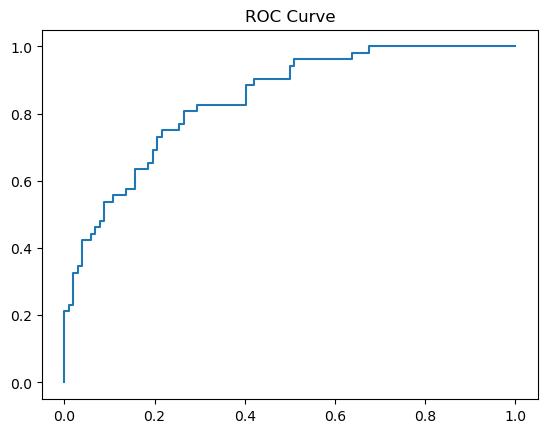

AUC: 0.8420060331825037
CV Accuracy: 0.768270944741533
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       102
           1       0.72      0.54      0.62        52

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.77      0.77      0.76       154



In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("diabetes.csv")
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model L2
model = LogisticRegression(penalty='l2', solver='liblinear')
model.fit(X_train, y_train)

# Predictions
y_prob = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc)

# Cross validation
scores = cross_val_score(model, X, y, cv=5)
print("CV Accuracy:", scores.mean())

# Report
print(classification_report(y_test, model.predict(X_test)))